In [1]:
import sys
sys.path.append('../functions')
import numpy as np
#import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
#import torch
import pandas as pd
import multiprocessing
import time
from sklearn.model_selection import ParameterGrid
import linear_sim_func  

In [2]:
!python3 main_linear.py

Runtime of the program is 1770.6280047893524 seconds


# One simulation 

In [25]:
n_sim = 1
#closeness_v = [0.5,0.1,0.01,0.001]
#closeness_v = [ -x for x in closeness_v]
N_v = [200]
N_test_v = [500]
p_v = [50]
error_sd_v = [1]
L_v = [0.95]
level_v = [1]
use_true_contour_v = [False]
n_boot_v = [500]
ridge_v = [False]
df_result = []
param_grid = {'N': N_v, 'N_test': N_test_v, 'p': p_v , 'error_sd': error_sd_v, 'L': L_v,
              'level': level_v,  'use_true_contour': use_true_contour_v, 'n_boot':n_boot_v, 'ridge':ridge_v}
param_grid = ParameterGrid(param_grid)
# "contain", "N", "N_test",
#                                 "p", "error_sd", "level", "use_true_contour",
#                                 "contain_scb","contain_CS_scb","Lower_bound",
#                                 "Upper_bound", "L1", "L2", "U1", "U2", "points_in_e1", 
#                                 "pre_mae", 'inner_points_num', 'outer_points_num' ,'true_set_points_num'
for param in param_grid:
    (contain, N, N_test, p, error_sd, level, use_true_contour, contain_scb, 
     contain_CS_scb, L, U, L1, L2, U1, U2, n_points, mae,
     range_v, inner_points_num,outer_points_num,true_set_points_num) = linear_sim_func.sim_linear(param['N'], param['N_test'], param['p'], param['error_sd'], 
                                                                                           param['L'],param['level'],param['use_true_contour'], 
                                                                                           param['n_boot'], param['ridge'],return_range = True)

In [26]:
mae

0.610364083223544

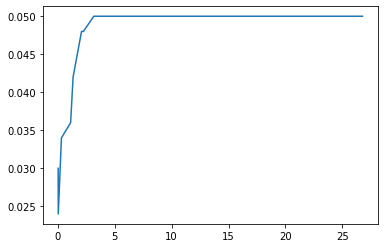

0.9500000000000028
0.974
True
0.752
0.9500000000000028
0.974
0.982
2


In [10]:
from matplotlib import pyplot as plt
x = [z[0] for z in range_v]
y = [z[1] for z in range_v]
plt.plot(x,y)
plt.show()
print(L)
print(U)
print(contain)
print(L1)
print(L2)
print(U1)
print(U2)
print(n_points)

# Multiple simulations (only works for MacOS)

In [6]:
from datetime import date
today = date.today()
date = today.strftime("%d%m%Y")
file_name = 'sim_results_boot_2000'+date+'.csv'
df_total = pd.DataFrame()
n_sim = 2
N_v = [50]
N_test_v = [500]
p_v = [160]
error_sd_v = [1]
L_v = [0.95]
level_v = [0.2]
use_true_contour_v = [False]
n_boot_v = [2000]
ridge_v = [True]
df_result = []
param_grid = {'N': N_v, 'N_test': N_test_v, 'p': p_v , 'error_sd': error_sd_v, 'L': L_v,
              'level': level_v,  'use_true_contour': use_true_contour_v, 'n_boot':n_boot_v,'ridge':ridge_v}
param_grid = ParameterGrid(param_grid)
start = time.time()
for param in param_grid:
    df = pd.DataFrame(param, index = [0])
    para_df = pd.DataFrame(np.repeat(df.values,n_sim, axis=0))
    para_df.columns = df.columns
    pool_obj = multiprocessing.Pool()
    cur_para = (n_sim*((param['N'], param['N_test'], param['p'], param['error_sd'], \
                      param['L'],param['level'],param['use_true_contour'], param['n_boot'], param['ridge']),))
    df_result.append(np.array(pool_obj.starmap(linear_sim_func.safe_sim_linear,cur_para)))
    pool_obj.close()
    pool_obj.join()
    df_ = pd.DataFrame(np.concatenate(df_result, axis = 0), 
                 columns = ["contain","contain_scb","contain_CS_scb","Lower_bound",
                            "Upper_bound", "L1", "L2", "U1", "U2", "points_in_e1", 
                            "pre_mae", 'inner_points_num', 'outer_points_num' ,'true_set_points_num'])
    df_ = pd.concat([para_df, df_], axis = 1)
    df_total = pd.concat([df_total,df_])
    df_total.to_csv(file_name, index = False)
end = time.time()
print('Runtime of the program is ' + str(end -start) + ' seconds')

Runtime of the program is 7.48319411277771 seconds


In [ ]:
df_total[df_total.use_true_contour==0].mean()

# Using scripts to run (for Windows Ubuntun)

In [28]:
!python3 main.py

Runtime of the program is 281.3313100337982 seconds
